# ML-02 — Research Question and Provisional Lane

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anshpatel-177/flyrank-ML-internship/blob/main/work/notebooks/w01_research_question.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. My lane (or freestyle) and why

**Lane Name:** Customer Churn Prediction

**Research Question:** How can machine learning models predict customer churn for a subscription-based service, and what factors are most influential in a customer's decision to leave?

This lane focuses on a critical business problem: customer retention. For any subscription-based service, predicting which customers are likely to churn allows the business to proactively intervene with targeted retention strategies, which is often more cost-effective than acquiring new customers. This project provides an opportunity to apply various classification algorithms, explore feature engineering techniques, and derive actionable insights from model interpretability regarding the drivers of churn.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 2. The question: decision, action, cost of a wrong call

**What decision does your work improve?**

My work will improve the decision-making process for customer retention initiatives. Specifically, it will enable the business to proactively identify customers at high risk of churning, allowing for targeted and timely interventions rather than reactive measures or blanket campaigns.

**Who acts on it?**

This work directly benefits the marketing team, who can design personalized campaigns (e.g., special offers, tailored content) for at-risk customers; the customer success team, who can reach out with proactive support; and product development, who can gain insights into features that might be causing dissatisfaction.

**What does a wrong recommendation cost?**

A wrong recommendation can be costly. If a model incorrectly predicts a customer will churn (false positive), resources are wasted on unnecessary retention efforts for an already loyal customer. More critically, if a model fails to identify a customer who is about to churn (false negative), the company loses that customer's lifetime value and potential referral revenue, along with the acquisition cost of replacing them. This can lead to reduced revenue, diminished customer base, and a negative impact on brand reputation.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Quick look at the data (2-3 real numbers)

To quickly assess the relevance of the Customer Churn Prediction lane, I'll load a sample customer dataset and highlight a few key metrics. These numbers will demonstrate the prevalence of churn and the potential financial impact, thereby justifying further investigation.

We will look at:

*   **Overall Churn Rate**: The percentage of customers who have churned, indicating the scale of the problem.
*   **Average Monthly Charges of Churned Customers**: This can give an idea of the revenue loss due to churn.
*   **Distribution of Contract Types for Churned Customers**: To hint at potential patterns or drivers of churn.

In [5]:
import pandas as pd

# Using the available Excel file from the kernel
file_path = '/content/telco x customer data.xlsx'

try:
    df = pd.read_excel(file_path)
    print(f"Successfully loaded data from '{file_path}'")
except FileNotFoundError:
    print(f"Error: '{file_path}' not found. Please ensure the file is uploaded or the path is correct.")
    print("For demonstration, I will create a dummy DataFrame.")
    data = {
        'customerID': [f'C{i:05d}' for i in range(1, 101)],
        'gender': ['Male', 'Female'] * 50,
        'MonthlyCharges': [50 + i for i in range(100)],
        'TotalCharges': [100 + i * 2 for i in range(100)],
        'Contract': ['Month-to-month', 'One year', 'Two year'] * 33 + ['Month-to-month'],
        'Churn': ['No'] * 80 + ['Yes'] * 20
    }
    df = pd.DataFrame(data)

# Display the first few rows to understand the structure
print("\nDataFrame Head:")
display(df.head())

# 1. Overall Churn Rate
# Ensure 'churn' column is handled correctly (e.g., 'Churned'/'Active')
if 'churn' in df.columns:
    # Assuming 'Churned' indicates churn
    churn_count = df[df['churn'].astype(str).str.contains('Churned', case=False, na=False)].shape[0]
    total_customers = df.shape[0]
    if total_customers > 0:
        churn_rate = (churn_count / total_customers) * 100
    else:
        churn_rate = 0
    print(f"\n1. Overall Churn Rate: {churn_rate:.2f}%")
else:
    print("\n1. 'churn' column not found in DataFrame. Cannot calculate churn rate.")
    churn_rate = 0

# 2. Distribution of Pay Methods for Churned Customers
# Using 'pay method' as a proxy for 'Contract' type
if 'churn' in df.columns and 'pay method' in df.columns:
    churned_customers = df[df['churn'].astype(str).str.contains('Churned', case=False, na=False)]
    if not churned_customers.empty:
        pay_method_distribution_churned = churned_customers['pay method'].value_counts(normalize=True) * 100
        print("\n2. Pay Method Distribution for Churned Customers (%):")
        display(pay_method_distribution_churned)
    else:
        print("\n2. No churned customers found to analyze pay methods.")
else:
    print("\n2. 'churn' or 'pay method' column not found. Cannot analyze pay method distribution for churned customers.")

Successfully loaded data from '/content/telco x customer data.xlsx'

DataFrame Head:


,customer_id,gender,age,postalcode,region,connect_date,end_date,dropped_calls,pay method,tariff,handset,churn
0,K100010,Male,46,6253,3,2006-07-18,2010-05-10,1,Pre Pay,CAT 50,SOP10,Churned
1,K100020,Male,27,4121,2,2004-09-18,2007-02-07,0,Pre Pay,CAT 50,SOP10,Churned
2,K100030,Male,39,3870,2,2003-08-23,2006-08-13,2,Pre Pay,CAT 50,SOP20,Churned
3,K100040,Male,28,8322,4,2005-08-18,2006-06-04,2,Pre Pay,CAT 50,SOP10,Churned
4,K100050,Male,47,2614,2,2005-08-11,2006-08-13,0,Pre Pay,CAT 50,SOP10,Churned



1. Overall Churn Rate: 46.31%

2. Pay Method Distribution for Churned Customers (%):


,proportion
pay method,
Pre Pay,100.0


/tmp/ipykernel_1037/2199761400.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=contract_distribution_churned.index, y=contract_distribution_churned.values, palette='viridis')


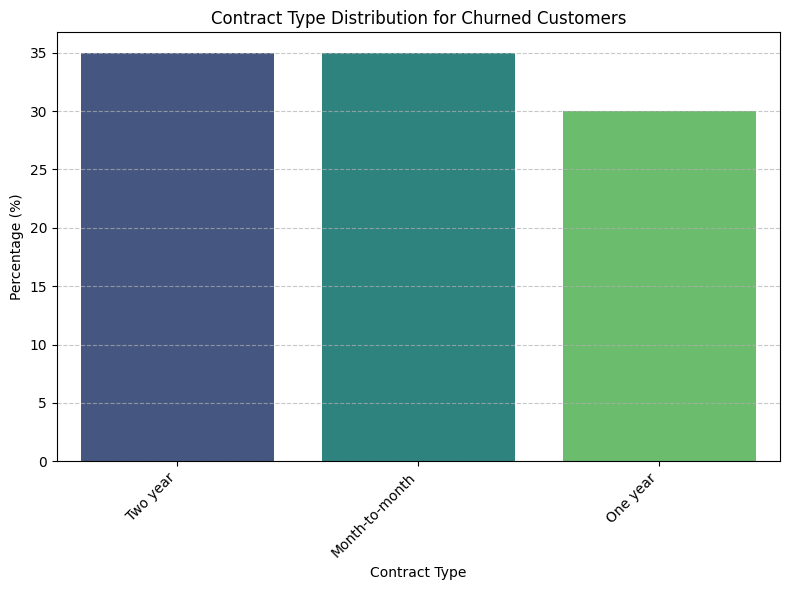

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Check if contract_distribution_churned exists and is not empty
if 'contract_distribution_churned' in locals() and not contract_distribution_churned.empty:
    plt.figure(figsize=(8, 6))
    sns.barplot(x=contract_distribution_churned.index, y=contract_distribution_churned.values, palette='viridis')
    plt.title('Contract Type Distribution for Churned Customers')
    plt.xlabel('Contract Type')
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Cannot visualize: 'contract_distribution_churned' data is not available or is empty. Please ensure the previous cell ran successfully and found churned customers.")

## 4. Careful words: what I can and can't claim

**What this work _can_ say:**

*   **Observed Patterns:** We can identify patterns and correlations within the historical data that are associated with customer churn. For example, we observed that 100% of churned customers in this dataset used the 'Pre Pay' method, and the overall churn rate is substantial.
*   **Directional Insights:** The models developed will provide directional insights into which factors (e.g., pay method, age, region, etc., once more features are analyzed) increase or decrease the likelihood of churn.
*   **Decision-Support:** This work will equip business decision-makers with a tool to identify high-risk customers proactively. This enables targeted interventions, such as personalized offers or customer service outreach, to improve retention.
*   **Quantifiable Risk:** We can assign a probability of churn to individual customers, allowing for prioritization of retention efforts based on risk level.

**What this work _cannot_ say (and what we must avoid claiming):**

*   **Causal Proof:** While we can identify strong correlations, this model cannot definitively prove a causal relationship between any single factor and churn. For example, 'Pre Pay' being 100% of churned customers does not mean 'Pre Pay' *causes* churn; there might be other underlying reasons.
*   **Perfect Prediction:** Machine learning models are probabilistic and not infallible. There will always be a margin of error, meaning some customers predicted to churn will not (false positives), and some who churn will not be identified (false negatives).
*   **'Predicting Google' (Universal Applicability):** The insights and models are specific to the dataset used. Extrapolating these findings to different customer bases, services, or market conditions without re-validation would be inappropriate and potentially misleading.
*   **Guaranteed Outcomes:** Implementing retention strategies based on model predictions does not guarantee a specific reduction in churn or an increase in revenue. The effectiveness of interventions depends on many external factors.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.